<a href="https://colab.research.google.com/github/jaison-leonardo/projects-ML-DL-iue/blob/main/Final_Project_IA_2_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Error:', e)

Mounted at /content/drive


**Instalamos dependecias si faltan**

In [2]:
import importlib, subprocess, sys, argparse, time, copy
from pathlib import Path
def pip_install(packages):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)

required = ['tqdm','pandas','scikit-learn','matplotlib','seaborn']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)

if missing:
    print('Instalando paquetes faltantes:', missing)
    pip_install(missing)
else:
    print('Paquetes de utilidad ya presentes.')

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader
    from torchvision import transforms, models, datasets
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tqdm import tqdm
    from sklearn.metrics import classification_report, confusion_matrix
    print('Torch version:', torch.__version__)
except Exception:
    print('PyTorch no encontrado — instala con pip. Ej: pip install torch torchvision')

Instalando paquetes faltantes: ['scikit-learn']
Torch version: 2.8.0+cu126


**Se realiza la extracción del dataset previamente preprocesado con con `train/`, `val/`, `test/`.**

In [3]:
import os, zipfile
zip_path = '/content/drive/MyDrive/Colab Notebooks/datasets/dataset-plants.zip'
dest = '/content/dataset'
os.makedirs(dest, exist_ok=True)
if os.path.exists(zip_path):
    print('Encontrado ZIP en Drive — descomprimiendo...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dest)
    print('Descomprimido en', dest)
else:
    print('No se encontró el ZIP en:', zip_path)

Encontrado ZIP en Drive — descomprimiendo...
Descomprimido en /content/dataset


In [4]:
import os, shutil
# Si processed está dentro de una carpeta anidada (ej: dataset/dataset-plants/processed), moverla al nivel raíz
# Buscar dónde quedó processed/
def find_processed_folder(start_path):
    for root, dirs, files in os.walk(start_path):
        if 'processed' in dirs:
            return os.path.join(root, 'processed')
    return None

processed_path = find_processed_folder('/content/dataset')
if processed_path and processed_path != '/content/dataset/processed':
    print(f"Encontrado 'processed' en: {processed_path}")
    print("Moviendo a /content/dataset/processed...")
    # Si ya existe /content/dataset/processed, eliminarla primero
    if os.path.exists('/content/dataset/processed'):
        shutil.rmtree('/content/dataset/processed')
    # Mover
    shutil.move(processed_path, '/content/dataset/processed')
    print("✓ Movido exitosamente.")
else:
    print("✓ 'processed' ya está en la ubicación correcta: /content/dataset/processed")

✓ 'processed' ya está en la ubicación correcta: /content/dataset/processed


**Configurar argumentos obligatorios por defecto**

In [5]:
def get_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data_dir', type=str, default='/content/dataset/processed', help='carpeta con train/ val/ test')
    parser.add_argument('--model_name', type=str, default='mobilenet_v2', choices=['mobilenet_v2','resnet18','efficientnet_b0'])
    parser.add_argument('--img_size', type=int, default=224)
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--epochs', type=int, default=20)
    parser.add_argument('--lr', type=float, default=1e-3)
    parser.add_argument('--workers', type=int, default=2)
    parser.add_argument('--resume', type=str, default=None)
    parser.add_argument('--use_amp', action='store_true', default=True)
    parser.add_argument('--output_dir', type=str, default='/content/drive/MyDrive/Colab Notebooks/models')
    parser.add_argument('--device', type=str, default='cuda' if torch.cuda.is_available() else 'cpu')
    return parser.parse_args([])

**Data loaders**

In [6]:
def create_dataloaders(data_dir, img_size, batch_size, workers):
    # Validar que data_dir existe y contiene train/val/test
    print(f"[DEBUG] Buscando dataset en: {data_dir}")
    if not os.path.exists(data_dir):
        print(f"ERROR: data_dir no existe: {data_dir}")
        if os.path.exists('/content/dataset'):
            print(f"[DEBUG] Contenido de /content/dataset:")
            for item in os.listdir('/content/dataset'):
                print(f"  - {item}")
        raise FileNotFoundError(f"No existe: {data_dir}")

    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val')
    test_dir = os.path.join(data_dir, 'test')

    for d in [train_dir, val_dir, test_dir]:
        if not os.path.exists(d):
            print(f"ERROR: No existe {d}")
            raise FileNotFoundError(f"No existe: {d}")

    print(f"[DEBUG] Encontrados train/, val/, test/ en {data_dir}")

    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    eval_transforms = transforms.Compose([
        transforms.Resize(int(img_size*1.1)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    train_ds = datasets.ImageFolder(train_dir, transform=train_transforms)
    val_ds = datasets.ImageFolder(val_dir, transform=eval_transforms)
    test_ds = datasets.ImageFolder(test_dir, transform=eval_transforms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

    class_names = train_ds.classes
    return train_loader, val_loader, test_loader, class_names

**Modelo (transfer learning)**

In [7]:

def build_model(model_name, num_classes, device):
    if model_name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == "resnet18":
        model = models.resnet18(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError("model not supported")
    return model.to(device)

**Entrenamiento y validación**

In [8]:
def train_model(model, dataloaders, device, criterion, optimizer, num_epochs, output_dir, use_amp=False):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_loader, val_loader, _ = dataloaders

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    scaler = None
    if use_amp and device.startswith("cuda"):
        scaler = torch.cuda.amp.GradScaler()

    try:
        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")
            # ---- train
            model.train()
            running_loss = 0.0
            running_corrects = 0
            total = 0
            for inputs, labels in tqdm(train_loader):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=(scaler is not None)):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data).item()
                total += inputs.size(0)

            epoch_loss = running_loss / total
            epoch_acc = running_corrects / total
            history["train_loss"].append(epoch_loss)
            history["train_acc"].append(epoch_acc)

            # ---- val
            model.eval()
            val_loss = 0.0
            val_corrects = 0
            val_total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    with torch.cuda.amp.autocast(enabled=(scaler is not None)):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    val_loss += loss.item() * inputs.size(0)
                    val_corrects += torch.sum(preds == labels.data).item()
                    val_total += inputs.size(0)
            val_epoch_loss = val_loss / val_total
            val_epoch_acc = val_corrects / val_total
            history["val_loss"].append(val_epoch_loss)
            history["val_acc"].append(val_epoch_acc)

            print(f" train_loss: {epoch_loss:.4f} acc: {epoch_acc:.4f} | val_loss: {val_epoch_loss:.4f} acc: {val_epoch_acc:.4f}")

            # guardar mejor modelo
            if val_epoch_acc > best_acc:
                best_acc = val_epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                os.makedirs(output_dir, exist_ok=True)
                best_path = os.path.join(output_dir, "best_model.pth")
                torch.save(model.state_dict(), best_path)
                print(f" --> Mejor modelo guardado: {best_path}")

    except KeyboardInterrupt:
        print("Entrenamiento interrumpido por usuario. Guardando último checkpoint...")
        os.makedirs(output_dir, exist_ok=True)
        torch.save(model.state_dict(), os.path.join(output_dir, "interrupted_model.pth"))
        raise

    time_elapsed = time.time() - since
    print(f"Entrenamiento completado en {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s. Mejor val_acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

**Evaluación final y métricas**

In [9]:
def evaluate(model, test_loader, device, class_names, output_dir):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    report = classification_report(targets, preds, target_names=class_names, digits=4, output_dict=True)
    df = pd.DataFrame(report).transpose()
    os.makedirs(output_dir, exist_ok=True)
    df.to_csv(os.path.join(output_dir, "classification_report.csv"))
    print("Reporte de clasificación guardado.")

    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
    print("Matriz de confusión guardada.")

# **Main**

**Preparación de datos**

In [10]:
args = get_args()
train_loader, val_loader, test_loader, class_names = create_dataloaders(args.data_dir, args.img_size, args.batch_size, args.workers)
dataloaders = (train_loader, val_loader, test_loader)
print(f"Clases detectadas: {class_names}")


[DEBUG] Buscando dataset en: /content/dataset/processed
[DEBUG] Encontrados train/, val/, test/ en /content/dataset/processed
Clases detectadas: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Blueberry___healthy', 'Cherry leaf', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach leaf', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato leaf early blight', 'Potato lea

**Construcción del modelo antes de la ejecución**

In [11]:
model = build_model(args.model_name, len(class_names), args.device)
# si se proporciona un checkpoint para reanudar, intentar cargarlo
if args.resume:
    if os.path.exists(args.resume):
        print(f"Cargando checkpoint desde {args.resume}")
        ckpt = torch.load(args.resume, map_location=args.device)
        # soportar distintos formatos de checkpoint
        if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
            model.load_state_dict(ckpt['model_state_dict'])
        else:
            try:
                model.load_state_dict(ckpt)
            except Exception as e:
                print(f"No se pudo cargar el checkpoint: {e}")
    else:
        print(f"Checkpoint no encontrado: {args.resume}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 144MB/s]


**Entrenamiento, evaluación y guardado del modelo**

/tmp/ipython-input-1638825706.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/20


  0%|          | 0/1244 [00:00<?, ?it/s]/tmp/ipython-input-1638825706.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
100%|██████████| 1244/1244 [04:26<00:00,  4.66it/s]
/tmp/ipython-input-1638825706.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


 train_loss: 0.8170 acc: 0.7634 | val_loss: 0.3758 acc: 0.8913
 --> Mejor modelo guardado: /content/drive/MyDrive/Colab Notebooks/models/best_model.pth
Epoch 2/20


100%|██████████| 1244/1244 [04:04<00:00,  5.08it/s]


...

 train_loss: 0.2010 acc: 0.9350 | val_loss: 0.1401 acc: 0.9570
Epoch 20/20


100%|██████████| 1244/1244 [04:01<00:00,  5.15it/s]


 train_loss: 0.1979 acc: 0.9368 | val_loss: 0.1117 acc: 0.9677
 --> Mejor modelo guardado: /content/drive/MyDrive/Colab Notebooks/models/best_model.pth
Entrenamiento completado en 91m 23s. Mejor val_acc: 0.9677


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Reporte de clasificación guardado.
Matriz de confusión guardada.


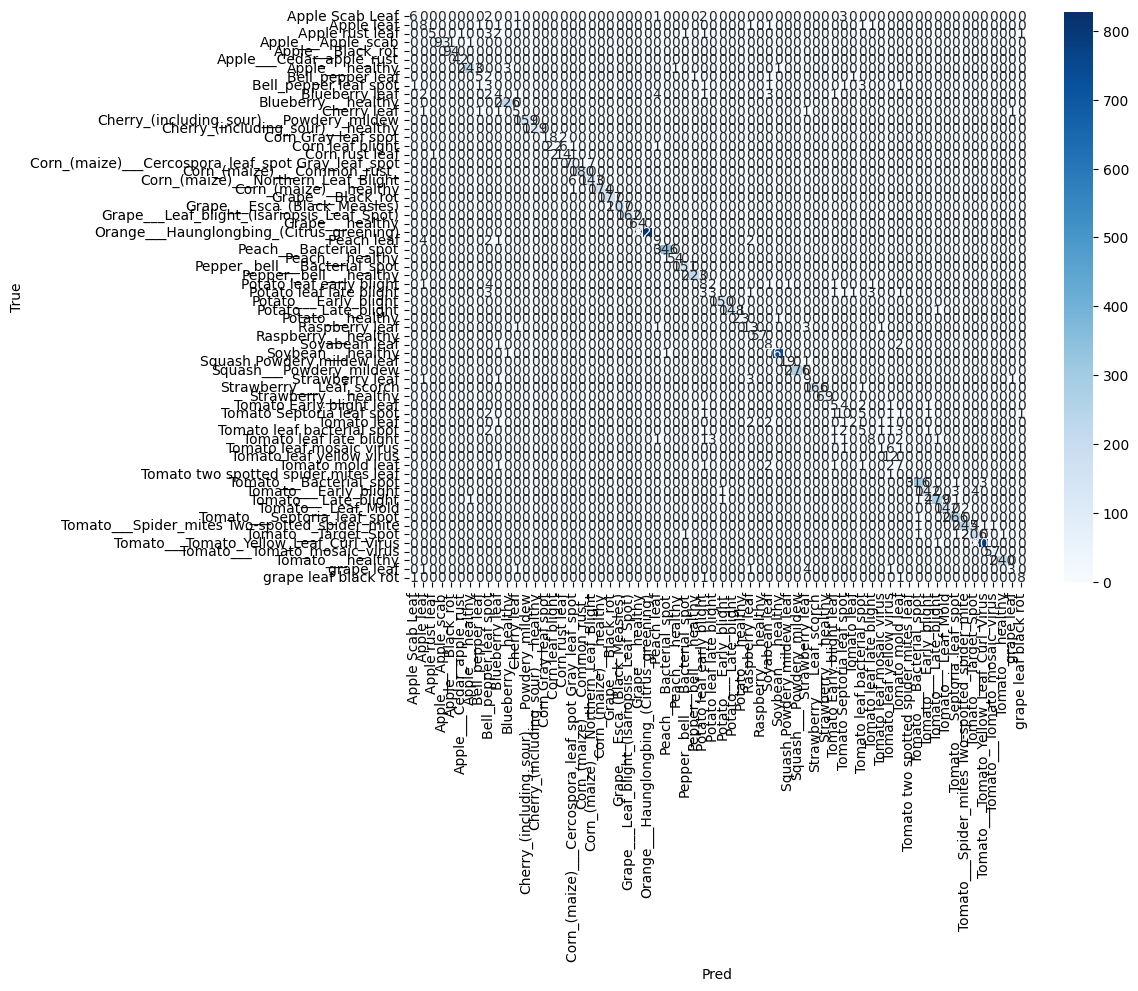

In [12]:
model, history = train_model(model, dataloaders, args.device, criterion, optimizer, args.epochs, args.output_dir, use_amp=args.use_amp)

# guardar ultimo checkpoint
os.makedirs(args.output_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(args.output_dir, "last_model.pth"))
evaluate(model, test_loader, args.device, class_names, os.path.join(args.output_dir, "training_logs"))